<a href="https://colab.research.google.com/github/gunathkalpitha/Sleep_Quality_prediction_ML_project/blob/main/Sleep_Quality_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
#step1:Download the data set

!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
print ("path to data set file: ",path)





Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
path to data set file:  /kaggle/input/sleep-health-and-lifestyle-dataset


In [57]:
#step2:Data preprocessing
#import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load CSV
data_di = os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv")
df = pd.read_csv(data_di)

#Preview example
# ── Quick look ──────────────────────────────────────────
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (374, 13)

First 5 rows:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [58]:
#step2:Data preprocessing
#Find data type and Missing values

# Check data types & missing values
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

#Updating
# Fix Sleep Disorder - NaN means "No Disorder"
df['Sleep Disorder'].fillna('None', inplace=True)

print("Sleep Disorder values:", df['Sleep Disorder'].value_counts())
print("Missing after fix:", df['Sleep Disorder'].isnull().sum())

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing values:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64
Sleep Disorder values: Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Na

/tmp/ipykernel_1311/1220405461.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna('None', inplace=True)


In [59]:
# Split Blood Pressure "120/80" → Systolic & Diastolic
# Split Blood Pressure & Drop unneeded columns
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Blood Pressure', 'Person ID','Stress Level'], inplace=True)


print("✅ Done! Shape:", df.shape)
print(df.dtypes)

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ Done! Shape:", df.shape)
print(df.dtypes)
print(df.head())

✅ Done! Shape: (374, 12)
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
BMI Category                object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object
✅ Done! Shape: (374, 12)
Gender                       int64
Age                          int64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
BMI Category                 int64
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder               int64
Systolic_BP                  int64
Diastolic_BP                 int64
dtype: object
   Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0       1   27    

In [60]:
#STEP 3: Define Target Variable

# Check current distribution
print("Quality of Sleep value counts:")
print(df['Quality of Sleep'].value_counts().sort_index())

# Convert Quality of Sleep score → 3 classes
def categorize_sleep(score):
    if score <= 5:
        return 0   # Poor
    elif score <= 7:
        return 1   # Fair
    else:
        return 2   # Good

df['Sleep_Quality'] = df['Quality of Sleep'].apply(categorize_sleep)
df.drop(columns=['Quality of Sleep',], inplace=True)

# 6. Define X, y
X = df.drop(columns=['Sleep_Quality'])
y = df['Sleep_Quality']



Quality of Sleep value counts:
Quality of Sleep
4      5
5      7
6    105
7     77
8    109
9     71
Name: count, dtype: int64


In [61]:
# Verify X does not contain target
print("Columns in X:")
print(X.columns.tolist())

print("\nTarget y name: Sleep_Quality")
print("y sample:", y[:5].tolist())

# Check neither column exists in X
if 'Quality of Sleep' in X.columns:
    print("\n❌ WARNING: Quality of Sleep still in X!")
elif 'Sleep_Quality' in X.columns:
    print("\n❌ WARNING: Sleep_Quality still in X!")
else:
    print("\n✅ Perfect! No target leakage!")

Columns in X:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP']

Target y name: Sleep_Quality
y sample: [1, 1, 1, 0, 0]

✅ Perfect! No target leakage!


In [62]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. SMOTE only on train
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Train size: (435, 11)
Test size: (75, 11)

Train class distribution:
Sleep_Quality
2    145
1    145
0    145
Name: count, dtype: int64

Test class distribution:
Sleep_Quality
1    37
2    36
0     2
Name: count, dtype: int64


In [63]:
# Scaling (re-run this before SVM)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Scaling done!")

✅ Scaling done!


In [64]:
#Train basic SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Basic SVM
svm_basic = SVC(random_state=42,probability=True)
svm_basic.fit(X_train_scaled, y_train)
y_pred_basic = svm_basic.predict(X_test_scaled)

print("Basic SVM Accuracy:", round(accuracy_score(y_test, y_pred_basic), 4))

Basic SVM Accuracy: 0.92


In [65]:
#Gridsearchcv to find better parameters

from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['rbf', 'linear'],
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),  # <-- THIS IS IMPORTANT!
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("\n✅ Best Parameters:", grid_search.best_params_)
print("✅ Best CV Accuracy:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
✅ Best CV Accuracy: 0.9862


Test Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

        Poor       0.67      1.00      0.80         2
        Fair       0.92      0.95      0.93        37
        Good       0.97      0.92      0.94        36

    accuracy                           0.93        75
   macro avg       0.85      0.95      0.89        75
weighted avg       0.94      0.93      0.93        75



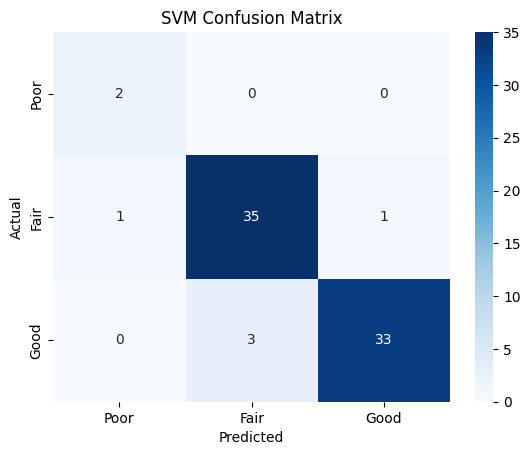

In [66]:
#Evaluate best SVM

best_svm = grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm,
      target_names=['Poor', 'Fair', 'Good']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poor','Fair','Good'],
            yticklabels=['Poor','Fair','Good'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [67]:
#Model2: Random Forest
# Model 2: Random Forest with stronger restrictions
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [3, 4, 5],        # shallower trees
    'min_samples_split': [10, 15, 20],     # harder to split
    'min_samples_leaf':  [4, 6, 8],        # bigger leaf nodes
    'max_features':      ['sqrt', 'log2']  # fewer features per tree
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=10,              # increased from 5 to 10
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("✅ Best Parameters:", grid_search_rf.best_params_)
print("✅ Best CV Accuracy:", round(grid_search_rf.best_score_, 4))

Fitting 10 folds for each of 162 candidates, totalling 1620 fits
✅ Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
✅ Best CV Accuracy: 0.9908


Train Accuracy: 0.9931
Test Accuracy:  0.9333
Difference:     0.0598

Classification Report:
              precision    recall  f1-score   support

        Poor       0.67      1.00      0.80         2
        Fair       0.92      0.95      0.93        37
        Good       0.97      0.92      0.94        36

    accuracy                           0.93        75
   macro avg       0.85      0.95      0.89        75
weighted avg       0.94      0.93      0.93        75



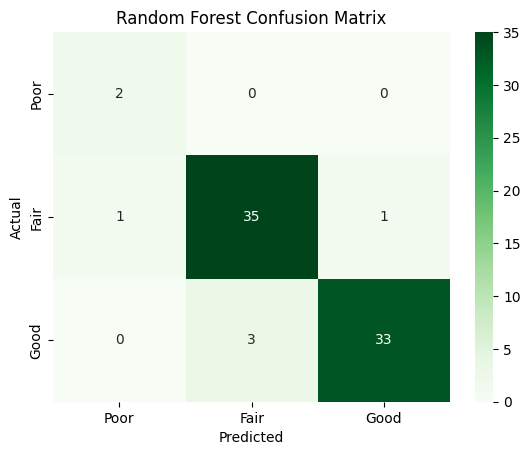

In [68]:
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# Compare train vs test to detect overfitting
train_acc = accuracy_score(y_train, best_rf.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred_rf)

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy: ", round(test_acc, 4))
print("Difference:    ", round(train_acc - test_acc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Poor', 'Fair', 'Good']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Poor','Fair','Good'],
            yticklabels=['Poor','Fair','Good'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

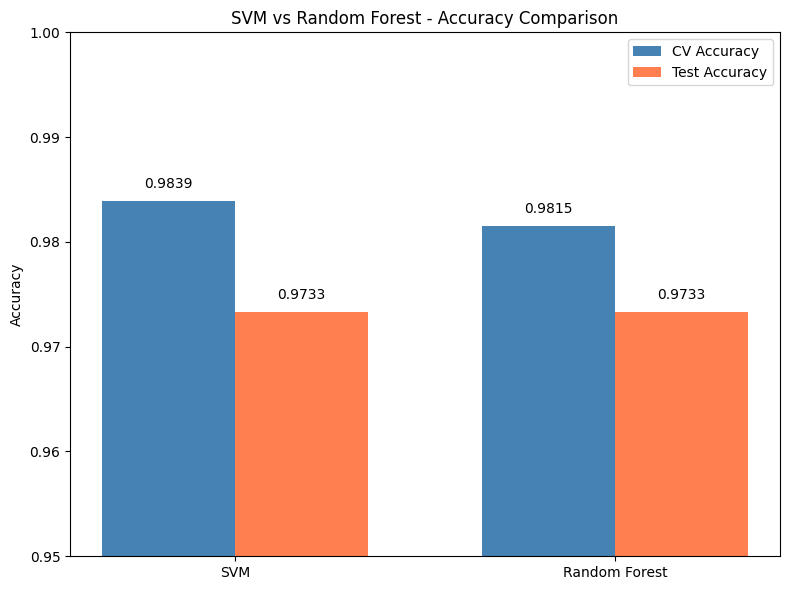

In [69]:
#Accuracy Comparison

import matplotlib.pyplot as plt
import numpy as np

# Accuracies
models = ['SVM', 'Random Forest']
cv_scores = [0.9839, 0.9815]
test_scores = [0.9733, 0.9733]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, cv_scores, width, label='CV Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_scores, width, label='Test Accuracy', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('SVM vs Random Forest - Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim([0.95, 1.00])
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

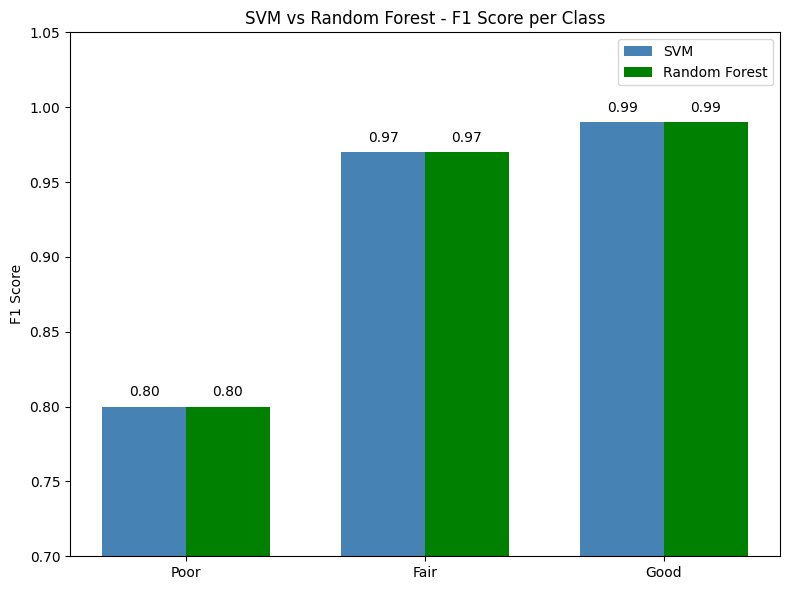

In [70]:
#Accuracy comarison-F1 score per class
# F1 Scores per class
classes = ['Poor', 'Fair', 'Good']
svm_f1 =  [0.80, 0.97, 0.99]
rf_f1  =  [0.80, 0.97, 0.99]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, svm_f1, width, label='SVM', color='steelblue')
bars2 = ax.bar(x + width/2, rf_f1,  width, label='Random Forest', color='green')

ax.set_ylabel('F1 Score')
ax.set_title('SVM vs Random Forest - F1 Score per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim([0.70, 1.05])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

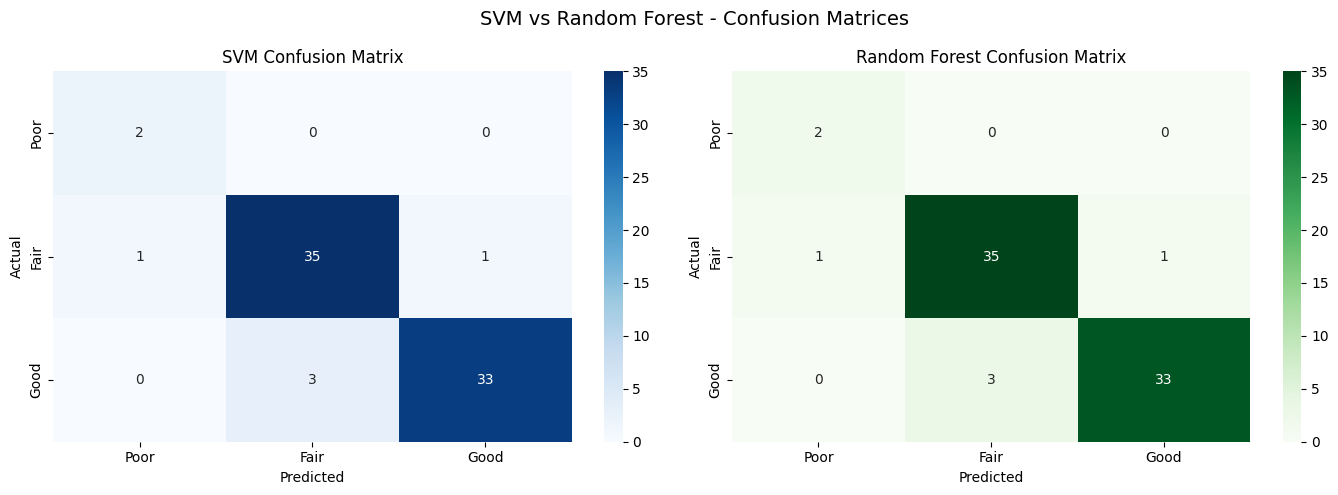

In [71]:
#Accuracy comarison-Side by Side Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Poor','Fair','Good'],
            yticklabels=['Poor','Fair','Good'])
axes[0].set_title('SVM Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# RF Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Poor','Fair','Good'],
            yticklabels=['Poor','Fair','Good'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('SVM vs Random Forest - Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

In [72]:
#Save Models in Colab
import joblib

# Save both models and scaler
joblib.dump(best_svm, 'svm_model.pkl')
joblib.dump(best_rf,  'rf_model.pkl')
joblib.dump(scaler,   'scaler.pkl')    # ← important! need for SVM prediction

print("✅ Models saved!")


✅ Models saved!


In [73]:
#Download to local

from google.colab import files

# Download all 3 files
files.download('svm_model.pkl')
files.download('rf_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
